# Hands-On AI for Science
### Aug 14 Afternoon: Where Is Waldo? — Convolutional Neural Nets
### Written by Kamila Abdiyeva for CS 440/ECE 448

In this notebook, we'll build a computer vision pipeline from scratch. Similar to the well-known puzzle "Where is Waldo?", we will search for specific patterns within an image. For this simplified version, we will focus on identifying blobs and bars rather than Waldo's canonical red-and-white stripes.

We'll start by implementing the fundamental mathematics of convolution, apply those operations to detect geometric patterns, explore gradient-based edge detection, and finally "train" a filter to recognize patterns automatically using gradient descent.

### INSTRUCTIONS
1) Solutions go in the **✍️ Your turn** cell
2) Only edit code inside the marked `TODO` blocks.
3) Do NOT change function names, arguments, or return types.

### Relevance to the real world

Most image, audio, and speech processing algorithms start with a few layers of <a href="https://en.wikipedia.org/wiki/Convolutional_neural_network">convolutional neural networks</a> that are used to extract local patterns in the input signal.  These convolutional layers are followed by several layers of Transformers, that are used to find long-term patterns.

A <a href="https://en.wikipedia.org/wiki/Vision_transformer">vision transformer</a> skips the convolutional layers, and feeds local image patches directly into the Transformer.  Since it chops the image up into patches, though, its behavior is best understood if you first understand convolutional networks.


### Self-contained Colab notebook

Everything you need is in this notebook — there is nothing to install and nothing to download. Just run the cells in order.


### Contents

1. [Correlation and Convolution](#convolution)
2. [Kernels for the detection of blobs and stripes](#blobs)
3. [Learning kernels for object detection](#learning)
   

### Helper code: `a14pm_getdata`

These are provided for you. Just run this cell — you do not need to edit it.

In [ ]:
import numpy as np

def generate_synthetic_data(width=30, height=30, num_shapes=2):
    """
    Generates a synthetic grayscale image with random blobs and bars.
    Returns:
        image: The noisy synthetic image.
        ground_truth: A list of dicts with shape type and center coordinates.
    """
    image = np.zeros((height, width))
    ground_truth = []
    shape_types = ['blob', 'bar']

    for i in range(num_shapes):
        # Randomly choose shape type: 0 for blob, 1 for bar
        shape_type = shape_types[i]
        y, x = np.random.randint(10, height-10), np.random.randint(10, width-10)

        if shape_type == 'blob':
            # Create a 5x5 circular blob
            for dy in range(-2, 3):
                for dx in range(-2, 3):
                    if dx**2 + dy**2 <= 4:
                        if 0 <= y+dy < height and 0 <= x+dx < width:
                            image[y+dy, x+dx] = 1.0
            ground_truth.append({'type': 'blob', 'pos': (y, x)})

        else:
            # Create a 1x7 vertical bar
            for dy in range(-3, 4):
                if 0 <= y+dy < height:
                    image[y+dy, x] = 1.0
            ground_truth.append({'type': 'bar', 'pos': (y, x)})

    # Add Gaussian noise
    image += np.random.normal(0, 0.1, image.shape)
    image = np.clip(image, 0, 1)

    return image, ground_truth

def generate_data(n_samples=100, size=20):
    X, Y = [], []
    for _ in range(n_samples):
        img = np.zeros((size, size))
        label = np.random.choice([0, 1]) # 0: bar, 1: blob
        y, x = np.random.randint(5, size-5), np.random.randint(5, size-5)

        if label == 1: # blob
            for dy in range(-2, 3):
                for dx in range(-2, 3):
                    if dx**2 + dy**2 <= 4:
                        img[y+dy, x+dx] = 1.0
        else: # bar
            img[y-3:y+4, x] = 1.0

        img += np.random.normal(0, 0.05, img.shape) # Add noise
        X.append(np.clip(img, 0, 1))
        Y.append(float(label))
    return np.array(X), np.array(Y)

def qualitative_check(gt, blob_pos, bar_pos, detection_radius=5):
    """
    Evaluates detection correctness against ground truth.
    Returns: dict with success counts per type.
    """
    results = {'blob': {'total': 0, 'detected': 0}, 'bar': {'total': 0, 'detected': 0}}

    for item in gt:
        gt_type = item['type']
        gt_pos = item['pos']

        # Adjust GT for valid padding offset (center of kernel)
        offset = 2 if gt_type == 'blob' else 3
        adjusted_gt = np.array([gt_pos[0] - offset, gt_pos[1] - offset])

        results[gt_type]['total'] += 1
        preds = blob_pos if gt_type == 'blob' else bar_pos

        if len(preds) > 0:
            distances = np.linalg.norm(preds - adjusted_gt, axis=1)
            if np.any(distances <= detection_radius):
                results[gt_type]['detected'] += 1

    return results

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple, Union

import numpy as np

<a id="convolution"></a>


# 1. Fundamentals: Correlation vs. Convolution



* Correlation

**Correlation** is a technique used to find pieces of one signal (the "image," $f[n]$) that match the pattern defined by another signal (the "kernel", $g[n]$).  This is done by shifting the kernel along the image, one pixel at a time; at each location, the output, $y[n]$, is the dot product of the image times the shifted kernel:

$$y[n]=\sum_m f[m] g[m+n]$$

**Convolution** is the same thing as correlation, but with the kernel flipped left-to-right and top-to-bottom first.  One reason for this flipping is that it makes the equations symmetric: You can flip-and-shift the kernel, or you can flip-and-shift the image, and the result is the same.

$$y[n] = \sum_m f[m] g[n-m] = \sum_m f[n-m] g[m]$$

The difference between correlation and convolution is very well described by this wikipedia image from the page on <a href="https://en.wikipedia.org/wiki/Convolution">convolution</a>.  Under each of the headings "Convolution," "Cross-correlation," "Autocorrelation", this image shows the following things:

* The image signal $f[n]$ is high-valued in the middle, and low-valued outside.  If this were an image, the middle part would be white, the outer parts would be black.
* The kernel signal $g[n]$ is a triangle.  If this were an image, it would be a gradient from white to black.
* The convolution or cross-correlation.
* The five line drawings below the convolution show the overlap of $f[n]$ with a shifted $g[n]$.  The product of the two signals is shaded.  The gray arrow, pointing upward, shows the point on $y[n]$ that is computed by adding up all of the shaded portion.
* The next two lines show that convolve(f,g)=convolve(g,f), but correlate(f,g)!=correlate(g,f)

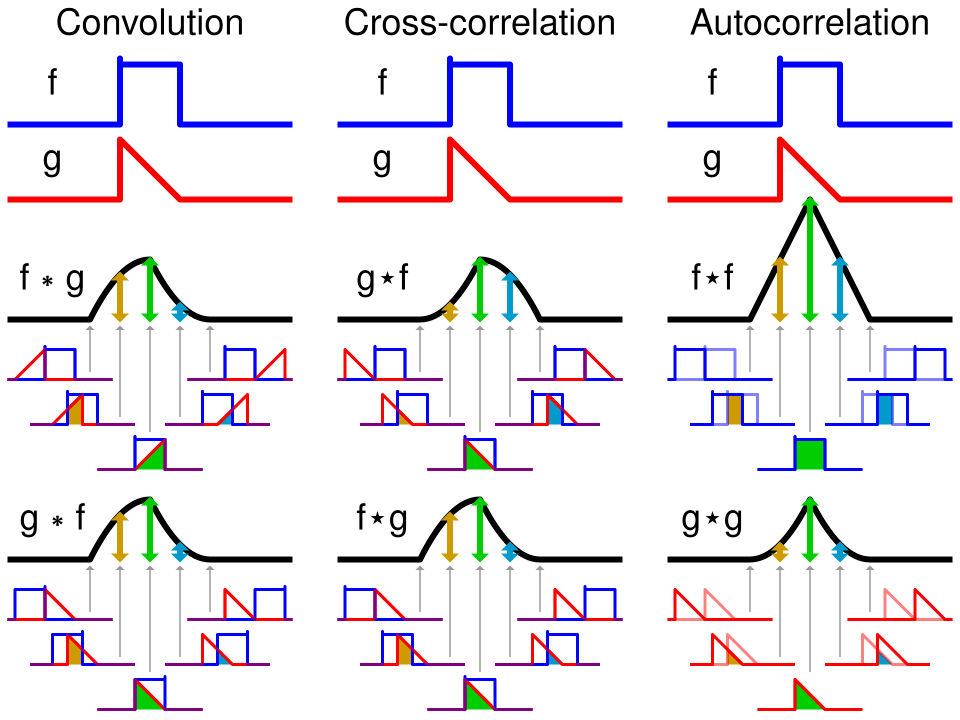

Some people like seeing a video of convolution.  If you would like to see a video:

* <a href="https://commons.wikimedia.org/wiki/File:Convolution_of_box_signals.gif">Here is a video of one-dimensional convolution</a>
* <a href="https://commons.wikimedia.org/wiki/File:Convolution_arithmetic_-_No_padding_no_strides.gif">Here is a video of two-dimensional convolution (an image in two dimensions, and a 2d kernel), with no padding and no strides.  This is the kind of convolution we will implement in this lecture.

### Functions to write

`correlation2d(image, kernel)`

* Implement 2D cross-correlation:

  * Slide the kernel across the image.

  * Multiply overlapping values and sum them.

`convolve2d(image, kernel)`

Implement 2D convolution.

  * Mathematically: You must flip the kernel 180 degrees (both horizontally and vertically) before performing the sliding sum.

  * Tip: You can implement this by flipping the kernel and then calling your correlation2d function.



**TODO**: Implement `convolve2d, correlation2d` in the **✍️ Your turn** cell

### ✍️ Your turn: write `convolve2d`, `correlation2d`, `detect_positions`, `detect_bar_gradient`

**This is where you write code.**  Fill them in below, then run this cell (Shift+Enter).  The cells underneath use them, so come back and re-run this cell every time you change them.

In [ ]:
import numpy as np

def convolve2d(image, kernel):
    """
    Computes the 2D convolution of an image with a given kernel.

    Args:
        image (np.ndarray): 2D array of shape (H, W)
        kernel (np.ndarray): 2D array of shape (Kh, Kw)

    Returns:
        np.ndarray: The convolved feature map without any padding.

    IMPORTANT:
      - No padding (!!! Spacial size of output feature map is different from image)
      - Stride = 1

    """

    H, W = image.shape
    kH, kW = kernel.shape

    if image.ndim != 2 or kernel.ndim != 2:
        raise ValueError("Input image  and kernel must be 2D.")
    if kH > H or kW > W:
        raise ValueError("Kernel cannot be larger than the input in any dimension.")

    response = None

    # TODO:  Your implementation here

    raise NotImplementedError

    return response

def correlation2d(image, kernel):
    """
    Computes the 2D cross-correlation of an image with a given kernel.

    Args:
        image (np.ndarray): 2D array of shape (H, W)
        kernel (np.ndarray): 2D array of shape (Kh, Kw)

    Returns:
        np.ndarray: The cross-correlation feature map without any padding.

    IMPORTANT:
      - No padding (!!! Spacial size of output is different from image)
      - No stride other than 1

    """

    H, W = image.shape
    kH, kW = kernel.shape

    if image.ndim != 2 or kernel.ndim != 2:
        raise ValueError("Input image and kernel must be 2D.")
    if kH > H or kW > W:
        raise ValueError("Kernel cannot be larger than the input in any dimension.")

    response = None

    # TODO:  Your implementation here

    raise NotImplementedError

    return response

# Part 2

def detect_positions(feature_map):
    """
    Identifies coordinates where the response is the highest
    """
    # TODO:  Your implementation here

    raise NotImplementedError
    positions = np.argmax(feature_map)
    positions = np.unravel_index(positions, feature_map.shape)
    positions = np.array([list(positions)])
    # positions2 = np.argwhere(feature_map == np.max(feature_map))
    # print("-----", positions, "-----", positions2)

    return positions

# Part 3

def detect_bar_gradient(image, scale=2):
    """
    Returns a 3x3 Horizontal Derivative Sobel kernel and the coordinates of global maxima
    after convolving with the input image.
    """
    kernel = None
    positions = None

    # TODO:  Your implementation here

    raise NotImplementedError

    # Define a standard 3x3 Horizontal Derivative Sobel filter
    kernel = np.array([[-1, 0, 1],[-scale, 0, scale], [-1, 0, 1]])
    # Perform convolution
    response = convolve2d(image, kernel)
    # Detect positions of global maxima
    positions = detect_positions(response)

    return kernel, positions

# Part 4

In [ ]:
import numpy as np

# Define a simple 3x3 input image
input_image = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

# Define a simple 2x2 asymmetric kernel
# Using an asymmetric kernel ensures convolution (flipped) and correlation are different
kernel = np.array([
    [1, 0],
    [0, -1]
])

print("Input Image:\n", input_image)
print("Kernel:\n", kernel)

# Perform cross-correlation
corr_output = correlation2d(input_image, kernel)
print("\nCross-Correlation Output:\n", corr_output)

# Perform convolution
conv_output = convolve2d(input_image, kernel)
print("\nConvolution Output:\n", conv_output)

# Verify that the outputs are different
if not np.allclose(corr_output, conv_output):
    print("\nSUCCESS: Convolution and Cross-Correlation produced different results for an asymmetric kernel.")
else:
    print("\nWARNING: Convolution and Cross-Correlation produced the same results!")

<a id="blobs"></a>

# 2. Synthetic Pattern Detection

Computers "see" features by scanning for regions with high mathematical response to specific kernels.

The wikipedia page on <a href="https://en.wikipedia.org/wiki/Object_detection">object detection</a> has some good explanatory images.  Basically, if we want to recognize an object, we need to create a kernel that has a pattern of pixels similar to the object we're looking for.  Correlation or convolution of the kernel with an image will result in a high output value at the position where a match is found.

 You will implement detectors for two geometric shapes: Blobs and Bars.

## Functions to write

`detect_positions(image, kernel)`

This one is written for you.  It convolves the image with the kernel, and then uses <a href="https://numpy.org/doc/stable/reference/generated/numpy.argmax.html">numpy.argmax</a> to find the row and column with the best match.

`detect_blob(image, k=5)`

* Construct a circular kernel of size $k \times k$ (where $k$ is odd). You can assume that circle radius = k//2.

* The kernel should be a binary circle mask (1.0 inside, 0.0 outside) normalized so that the sum of all weights equals 1.0.

* Perform convolution and return the kernel and the coordinates of the global maxima.

`detect_bar(image, k=7)`

* Construct a vertical bar kernel of size $k \times k$.

* The kernel should be all zeros except for a vertical line of ones in the center column, normalized to sum to 1.0.

* Return the kernel and the detected positions of the global maxima.


### ✍️ Your turn: write `detect_blob`, `detect_bar`

**This is where you write code.**  Fill them in below, then run this cell (Shift+Enter).  The cells underneath use them, so come back and re-run this cell every time you change them.

In [ ]:
def detect_blob(image, k=5):
    """
    Returns a simple kxk kernel designed to detect blobs (normalize).
    The kernel size and shape depend on k.

    You can use as blob radius**2 = (center)**2
    """
    kernel = None
    positions = None
    # TODO:  Your implementation here

    raise NotImplementedError

    return kernel, positions

def detect_bar(image, k=7):
    """
    Returns a kxk kernel designed to detect vertical bars.
    All values in filter should be 0 except central vertical line
    """
    kernel = None
    positions = None

    # TODO:  Your implementation here

    raise NotImplementedError
    center = k//2
    kernel = np.zeros((k,k))
    kernel[:, center]=1.0
    kernel = kernel/np.sum(kernel)

    response = convolve2d(image, kernel)
    positions = detect_positions(response)

    return kernel, positions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Data
img, gt = generate_synthetic_data(num_shapes=2)

# 2. Run Detectors
# blob_k = detect_blob()
# bar_k = detect_bar()

# Example visualization
plt.figure(figsize=(15, 3))
plt.subplot(151)
plt.title("Synthetic Image")
plt.imshow(img, cmap='gray')

# Initialize blob_pos and bar_pos to empty arrays or None
# to handle cases where detection fails or isn't implemented
blob_pos = np.array([])
bar_pos = np.array([])

# Detect Blobs
blob_k, blob_pos = detect_blob(img)
blob_map = convolve2d(img, blob_k)
plt.subplot(152)
plt.title("Blob Detections")
plt.imshow(blob_map, cmap='hot')
plt.plot(blob_pos[:, 1], blob_pos[:, 0], 'cx')

# Detect Bars
bar_k, bar_pos = detect_bar(img)
bar_map = convolve2d(img, bar_k)

plt.subplot(153)
plt.title("Bar Detections")
plt.imshow(bar_map, cmap='hot')
plt.plot(bar_pos[:, 1], bar_pos[:, 0], 'cx')

plt.subplot(154)
plt.title("Blob Kernel")
plt.imshow(blob_k, cmap='gray')

plt.subplot(155)
plt.title("Bar Kernel")
plt.imshow(bar_k, cmap='gray')

<a id="learning"></a>

# 3. Learning Kernels for Object Detection

In the previous section, you manually engineered kernels to detect blobs and bars. This process is known as feature engineering and was the standard in computer vision for decades.

Modern AI doesn't rely on human-designed filters. Instead, kernels are "learned" from data. You will implement a simplified training loop to find a $3 \times 3$ kernel that can distinguish a Blob (Label 1) from a Bar (Label 0).

`train_classifier(images, labels, epochs=100)`

Optimize a $3 \times 3$ kernel $g[m_1,m_2]$ using Stochastic Gradient Descent (SGD). SGD is an optimization algorithm that iteratively updates model parameters (weights) by calculating the gradient of the loss function for **a single training example** at a time:

* Initialize: Start with a 3x3 kernel of small random values.

* Forward Pass: Convolve the image (using `convolve2d`) and use `get_positions` to find the position of the peak response ($[n_1^*,n_2^*]$) and the value of the peak response ($max$).

* Loss: Use Mean Squared Error (MSE): $L = (max - tgt)^2$, where $tgt$ is the desired output:

  $tgt = 1.0$ if the image contains a blob.

  $tgt = 0.0$ if the image contains a bar.

* Backprop: Calculate the gradient of the loss with respect to the kernel weights, which should be the image flipped and shifted by the max coordinate, $f[n_1^*-m_1,n_2^*-m_2]$, scaled by the error $2(max-tgt)$.

* Update: $g[m_1,m_2] = g[m_1,m_2] - (lr \times gradient)$

* Adjust hyperparameter $lr$ (learning rate) to achieve the best performance.

  Learning Rate ($lr$): A hyperparameter that controls how much to change the model in response to the estimated error each time the model weights are updated.

  If $lr$ is too small, training will take a very long time to converge.

  If $lr$ is too large, it may cause the weights to oscillate wildly or even diverge.

* Dataset Setup: Use the provided synthetic generator above to create a balanced set of blob and bar images.

`predict(image, kernel, threshold=0.5):`

*   perform convolution with learned kernel using `convolve2d`
*   find the global maxima using `detect_positions`
*   return  global maxima > threshold, global maxima



### To think about

 - Interpretability: After training, what does your learned kernel look like? Does it resemble the manual blob/bar kernels you designed in Q2?



### ✍️ Your turn: write `train_classifier`, `predict`

**This is where you write code.**  Fill them in below, then run this cell (Shift+Enter).  The cells underneath use them, so come back and re-run this cell every time you change them.

In [ ]:
def train_classifier(images, labels, epochs=100, lr=0.01):
    """
    Optimizes a 3x3 kernel to distinguish between two patterns (e.g., blobs vs bars).

    Args:
        images (np.ndarray): Array of shape (N, H, W) containing training images.
        labels (np.ndarray): Array of shape (N,) containing 1.0 (blobs) or 0.0 (bars).
        epochs (int): Number of times to iterate over the dataset.
        lr (float): Learning rate for gradient descent.

    Returns:
        np.ndarray: The learned 3x3 kernel.
    """

    # TODO:  Your implementation here

    raise NotImplementedError

    # 1. Initialization
    # Initialize a 3x3 kernel with small random values
    kernel = None
    # kernel = np.random.rand(3,3)
    kernel = np.random.normal(0, 0.01, (3, 3))
    # return kernel
    # exit()


    for epoch in range(0, epochs):
        for i in range(0, len(images)):
    # --- 2. Forward Pass ---
    # Perform convolution using your convolve2d implementation
            img, y =  images[i], labels[i]
            feature_map = convolve2d(img, kernel)
    # Global Max Pooling: Find the maximum value (prediction)
    # and its (row, col) coordinates in the feature map
            positions = detect_positions(feature_map)

            acc_grad = np.zeros((3,3))

            for position in positions:
                # print(position)
                predicted = feature_map[position[0], position[1]]
                # print(predicted)

    # --- 3. Compute Loss ---
    # Calculate Mean Squared Error

                error = (predicted-y)**2

    # --- 4. Backpropagation (Simplified) ---
    # Calculate the gradient of the loss with respect to the kernel.
    # Use the chain rule
                gradient_loss = 2*(predicted-y)
                image_patch = img[position[0]:position[0]+3, position[1]:position[1]+3]
                gradient_max_conv = gradient_loss*image_patch
                acc_grad+=gradient_max_conv

    # --- 5. Update Weights ---
    # Apply the gradient descent update rule: K = K - (lr * gradient)
            acc_grad = np.rot90(acc_grad, 2)
            # print("------", len(positions))
            kernel -=(lr * acc_grad/(len(positions)))


    return kernel

def predict(image, kernel, threshold=0.5):
    """
    Uses a trained kernel to recognize if a pattern is present.
    """
    # TODO:  Your implementation here

    raise NotImplementedError

    max_response = None
    # 1. Convolve image with learned kernel
    map = convolve2d(image, kernel)
    # 2. Find max response
    max_response = np.max(map)
    return max_response > threshold, max_response

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a synthetic dataset of blobs and bars
print("Generating dataset...")
X, y = generate_data(200)

plt.figure(figsize=(10, 4))

# Find a sample for 'bar' (Label 0)
bar_indices = np.where(y == 0.0)[0]
if len(bar_indices) > 0:
    idx_bar = np.random.choice(bar_indices)
    plt.subplot(1, 2, 1)
    plt.imshow(X[idx_bar], cmap='gray')
    plt.title(f"Sample: Bar (Label 0)\nIndex: {idx_bar}")

# Find a sample for 'blob' (Label 1)
blob_indices = np.where(y == 1.0)[0]
if len(blob_indices) > 0:
    idx_blob = np.random.choice(blob_indices)
    plt.subplot(1, 2, 2)
    plt.imshow(X[idx_blob], cmap='gray')
    plt.title(f"Sample: Blob (Label 1)\nIndex: {idx_blob}")

plt.tight_layout()
plt.show()

# 2. Split into training and testing sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 3. Call train_classifier
print("Training...")
learned_filter = train_classifier(X_train, y_train, epochs=2, lr=0.1)

# 4. Evaluate and visualize the learned kernel
correct = 0
predictions = []
responses = []
for i in range(len(X_test)):
    is_blob, resp = predict(X_test[i], learned_filter, threshold=0.5)
    pred_label = 1.0 if is_blob else 0.0
    predictions.append(pred_label)
    responses.append(resp)
    if pred_label == y_test[i]:
        correct += 1

print(f"\nFinal Test Accuracy: {correct/len(X_test) * 100:.2f}%")

# Visualize Predictions on random test samples
plt.figure(figsize=(12, 6))
plt.suptitle("Test Set Predictions", fontsize=16)
sample_indices = np.random.choice(len(X_test), 8, replace=False)

for i, idx in enumerate(sample_indices):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[idx], cmap='gray')

    gt = int(y_test[idx])
    pred = int(predictions[idx])
    conf = responses[idx]

    # Green if correct, Red if wrong
    color = 'green' if gt == pred else 'red'
    label_names = {0: "Bar", 1: "Blob"}

    plt.title(f"GT: {label_names[gt]}\nPred: {label_names[pred]}\nScore: {conf:.2f}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.title("Learned 3x3 Filter Weights")
plt.imshow(learned_filter, cmap='gray', interpolation='nearest')
plt.colorbar(label='Weight Intensity')
plt.show()